# Day 06｜Logit Lens: When does the model start knowing the answer?

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/HowardHsuuu/mech-interp-ironman-series/blob/main/notebooks/day06_logit_lens.ipynb)

We use **Qwen2.5-0.5B**, **TransformerLens**, and the **Logit Lens** to project intermediate residual-stream states into vocabulary logits. The factual-recall example follows `Taiwan → Taipei`. In Qwen's tokenizer, ` Taipei` is one token while ` Taichung` is split into multiple tokens, so the layer-wise comparison uses Taichung's first token as an explicitly labeled proxy.

## 1. Setup

In [1]:
%env PIP_DISABLE_PIP_VERSION_CHECK=1
%pip install -q "transformer-lens==2.18.0" "transformers==4.57.6" "matplotlib==3.10.8"

env: PIP_DISABLE_PIP_VERSION_CHECK=1


Note: you may need to restart the kernel to use updated packages.


In [2]:
import warnings

warnings.filterwarnings("ignore", message="IProgress not found.*")
warnings.filterwarnings("ignore", category=DeprecationWarning)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from transformer_lens import HookedTransformer

MODEL_NAME = "Qwen/Qwen2.5-0.5B"
PROMPT = "The capital of Taiwan is"
TARGET_ANSWER = " Taipei"
COMPETING_ANSWER = " Taichung"

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cpu


## 2. Load and freeze Qwen2.5-0.5B

In [3]:
print("Loading Qwen2.5-0.5B with TransformerLens...")
model = HookedTransformer.from_pretrained(MODEL_NAME, device=device)
model.eval()

for parameter in model.parameters():
    parameter.requires_grad_(False)

print(f"Model: {MODEL_NAME}")
print(f"Transformer blocks: {model.cfg.n_layers}")
print(f"Residual-stream width: {model.cfg.d_model}")
print("Model parameters frozen:", not any(p.requires_grad for p in model.parameters()))

Loading Qwen2.5-0.5B with TransformerLens...


`torch_dtype` is deprecated! Use `dtype` instead!


Loaded pretrained model Qwen/Qwen2.5-0.5B into HookedTransformer
Model: Qwen/Qwen2.5-0.5B
Transformer blocks: 24
Residual-stream width: 896
Model parameters frozen: True


## 3. Check tokenization and the model's final prediction

We use the series' factual-recall prompt exactly as written: `The capital of Taiwan is`. Before interpreting any logits, we inspect how both candidate answers are tokenized. The model's actual top prediction is an experimental result rather than something we force by rewriting the prompt.

In [4]:
def tokenize_completion(text):
    token_ids = model.to_tokens(text, prepend_bos=False)[0]
    token_pieces = [model.to_single_str_token(int(token_id)) for token_id in token_ids]
    return token_ids, token_pieces


target_ids, target_pieces = tokenize_completion(TARGET_ANSWER)
competing_ids, competing_pieces = tokenize_completion(COMPETING_ANSWER)

assert len(target_ids) == 1, "This demonstration expects Taipei to be one token."
target_id = int(target_ids[0])
competing_first_id = int(competing_ids[0])
competing_first_piece = competing_pieces[0]

print(f"{TARGET_ANSWER!r} tokenizes as: {target_pieces}  ids={target_ids.tolist()}")
print(f"{COMPETING_ANSWER!r} tokenizes as: {competing_pieces}  ids={competing_ids.tolist()}")
print(
    "Layer-wise proxy: "
    f"logit({TARGET_ANSWER!r}) − logit({competing_first_piece!r}), "
    f"where {competing_first_piece!r} is the first token of {COMPETING_ANSWER!r}."
)

with torch.inference_mode():
    logits, cache = model.run_with_cache(PROMPT)

final_logits = logits[0, -1]
final_probs = final_logits.softmax(dim=-1)
top_probs, top_ids = torch.topk(final_probs, k=10)

print()
print("Prompt:", repr(PROMPT))
print("Final next-token predictions:")
for rank, (token_id, probability) in enumerate(zip(top_ids, top_probs), start=1):
    token = model.to_single_str_token(token_id.item())
    print(f"{rank:>2}. {token!r:>12}  probability={probability.item():.4f}")

' Taipei' tokenizes as: [' Taipei']  ids=[96345]
' Taichung' tokenizes as: [' Ta', 'ich', 'ung']  ids=[23291, 713, 2185]
Layer-wise proxy: logit(' Taipei') − logit(' Ta'), where ' Ta' is the first token of ' Taichung'.

Prompt: 'The capital of Taiwan is'
Final next-token predictions:
 1.   ' located'  probability=0.1430
 2.        ' __'  probability=0.1136
 3.     ' known'  probability=0.0919
 4.    ' ______'  probability=0.0692
 5.      ' ____'  probability=0.0625
 6.       ' the'  probability=0.0546
 7.    ' Taipei'  probability=0.0507
 8.         ' a'  probability=0.0330
 9.         ' ('  probability=0.0254
10.         '\n'  probability=0.0202


## 4. Apply the Logit Lens

`accumulated_resid` returns the residual-stream state at each layer boundary for the final prompt position. We apply the model's final normalization and unembedding matrix to every state:

```text
intermediate residual state → final normalization → unembedding → vocabulary logits
```

In [5]:
residual_stack, labels = cache.accumulated_resid(
    layer=-1,
    pos_slice=-1,
    return_labels=True,
)

# Shape: (residual states, selected positions, d_model)
residual_stack = residual_stack.squeeze(1)
layer_logits = model.unembed(model.ln_final(residual_stack))

print("Residual states:", labels)
print("Residual stack shape:", tuple(residual_stack.shape))
print("Layer logits shape:", tuple(layer_logits.shape))

Residual states: ['0_pre', '1_pre', '2_pre', '3_pre', '4_pre', '5_pre', '6_pre', '7_pre', '8_pre', '9_pre', '10_pre', '11_pre', '12_pre', '13_pre', '14_pre', '15_pre', '16_pre', '17_pre', '18_pre', '19_pre', '20_pre', '21_pre', '22_pre', '23_pre', 'final_post']
Residual stack shape: (25, 896)
Layer logits shape: (25, 151936)


In [6]:
layer_probs = layer_logits.softmax(dim=-1)

rows = []
for index, label in enumerate(labels):
    top_probs, top_ids = torch.topk(layer_probs[index], k=5)
    top_tokens = [model.to_single_str_token(token_id.item()) for token_id in top_ids]

    rows.append(
        {
            "Residual state": label,
            "Top prediction": repr(top_tokens[0]),
            "Top probability": top_probs[0].item(),
            "Top-5 tokens": ", ".join(repr(token) for token in top_tokens),
            f"Logit {TARGET_ANSWER!r}": layer_logits[index, target_id].item(),
            f"Logit {competing_first_piece!r} (Taichung first token)": layer_logits[
                index, competing_first_id
            ].item(),
        }
    )

results = pd.DataFrame(rows)
display(results.round(3))

,Residual state,Top prediction,Top probability,Top-5 tokens,Logit ' Taipei',Logit ' Ta' (Taichung first token)
0,0_pre,' is',1.000,"' is', ' ', ',', ' (', ' was'",-5.857,13.963
1,1_pre,"'\';"";\n'",0.068,"'\';"";\n', 'hape', '醾', 'otope', ' CH'",1.781,2.383
2,2_pre,""".','""",0.037,""".','"", '"")));', '\';"";\n', "":')"", '.""));\n'",-1.568,0.802
3,3_pre,""".','""",0.204,""".','"", "":')"", '.""));\n', '\';"";\n', ""']));""",-1.528,1.296
4,4_pre,""".','""",0.271,""".','"", '\';"";\n', '�', "":')"", "".');\r\n""",-3.097,0.520
5,5_pre,""".','""",0.475,""".','"", '�', '\\"""",', '\';"";\n', 'PEND'",-2.375,-0.428
6,6_pre,"'\';"";\n'",0.107,"'\';"";\n', ""')));\n\n"", 'izador', ""');\n\n\n\n...",-2.983,1.556
7,7_pre,'?>>',0.103,"'?>>', ""','');\n"", ""');\n\n\n\n"", ""')));\n\n"",...",-3.001,0.541
8,8_pre,'?>>',0.250,"'?>>', ""',...\n"", "".','"", ""','');\n"", '\';"";\n'",-6.931,-0.746
9,9_pre,'?>>',0.140,"'?>>', ""')));\n\n"", '"",@""', '*****\r\n', '\';""...",-5.170,1.209


## 5. Track the first decoding decision across layers

Because `Taichung` contains multiple tokens, this plot does **not** compare the complete strings `Taipei` and `Taichung`. It compares the next-token evidence for directly producing ` Taipei` against beginning the multi-token ` Taichung` path with its first token.

In [7]:
target_logits = layer_logits[:, target_id].detach().cpu().numpy()
competing_first_logits = layer_logits[:, competing_first_id].detach().cpu().numpy()
proxy_margin = target_logits - competing_first_logits

trajectory = pd.DataFrame(
    {
        "Residual state": labels,
        f"Logit {TARGET_ANSWER!r}": target_logits,
        f"Logit {competing_first_piece!r} (Taichung first token)": competing_first_logits,
        "First-token proxy margin": proxy_margin,
    }
)
display(trajectory.round(3))

,Residual state,Logit ' Taipei',Logit ' Ta' (Taichung first token),First-token proxy margin
0,0_pre,-5.857000,13.963,-19.820
1,1_pre,1.781000,2.383,-0.602
2,2_pre,-1.568000,0.802,-2.371
3,3_pre,-1.528000,1.296,-2.823
4,4_pre,-3.097000,0.520,-3.617
5,5_pre,-2.375000,-0.428,-1.947
6,6_pre,-2.983000,1.556,-4.539
7,7_pre,-3.001000,0.541,-3.542
8,8_pre,-6.931000,-0.746,-6.185
9,9_pre,-5.170000,1.209,-6.379


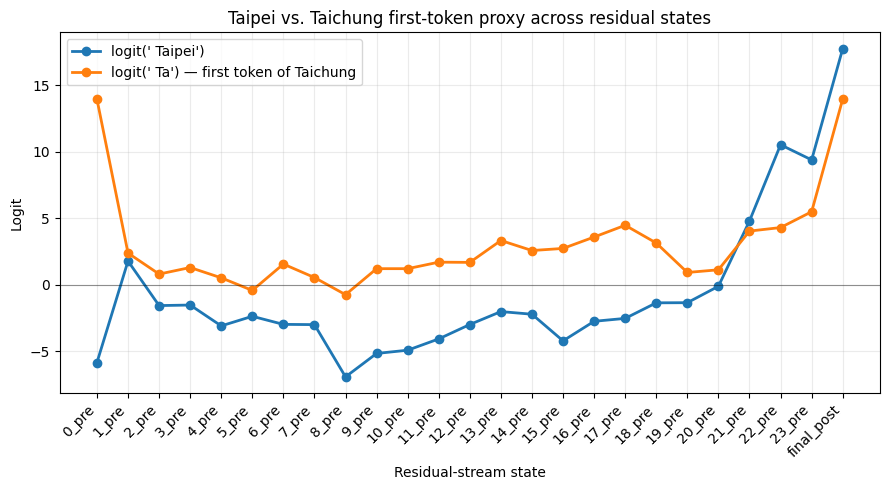

In [8]:
x = np.arange(len(labels))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(x, target_logits, marker="o", linewidth=2, label=f"logit({TARGET_ANSWER!r})")
ax.plot(
    x,
    competing_first_logits,
    marker="o",
    linewidth=2,
    label=f"logit({competing_first_piece!r}) — first token of Taichung",
)
ax.axhline(0, color="black", linewidth=0.8, alpha=0.4)
ax.set_title("Taipei vs. Taichung first-token proxy across residual states")
ax.set_xlabel("Residual-stream state")
ax.set_ylabel("Logit")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
plt.show()

## 6. Score the complete multi-token answers

For a complete answer comparison, we use teacher forcing: append each candidate answer to the prompt, compute every answer token's conditional log-probability, and add them to obtain the sequence log-likelihood.

The total log-likelihood is the probability score of the token sequence under the model. The mean per-token log-probability is also shown as a length-normalized diagnostic, since raw sums tend to favor shorter candidates. This complete sequence score is separate from the layer-wise first-token proxy above.

In [9]:
def score_completion(prompt, completion):
    prompt_tokens = model.to_tokens(prompt)
    full_tokens = model.to_tokens(prompt + completion)
    prompt_length = prompt_tokens.shape[1]

    if not torch.equal(full_tokens[:, :prompt_length], prompt_tokens):
        raise ValueError("The completion changed the prompt's tokenization boundary.")

    with torch.inference_mode():
        full_logits = model(full_tokens)

    completion_ids = full_tokens[0, prompt_length:]
    prediction_logits = full_logits[0, prompt_length - 1 : -1]
    token_log_probs = prediction_logits.log_softmax(dim=-1).gather(
        dim=-1,
        index=completion_ids.unsqueeze(-1),
    ).squeeze(-1)
    token_pieces = [model.to_single_str_token(int(token_id)) for token_id in completion_ids]

    token_table = pd.DataFrame(
        {
            "Answer": completion,
            "Token": token_pieces,
            "Token id": completion_ids.detach().cpu().numpy(),
            "Conditional log-probability": token_log_probs.detach().cpu().numpy(),
        }
    )
    return token_table, token_log_probs.sum().item(), token_log_probs.mean().item()


token_tables = []
sequence_rows = []
for answer in (TARGET_ANSWER, COMPETING_ANSWER):
    token_table, total_log_prob, mean_log_prob = score_completion(PROMPT, answer)
    token_tables.append(token_table)
    sequence_rows.append(
        {
            "Complete answer": answer,
            "Number of tokens": len(token_table),
            "Total log-likelihood": total_log_prob,
            "Mean log-probability per token": mean_log_prob,
        }
    )

display(pd.concat(token_tables, ignore_index=True).round(3))
display(pd.DataFrame(sequence_rows).round(3))

,Answer,Token,Token id,Conditional log-probability
0,Taipei,Taipei,96345,-2.983
1,Taichung,Ta,23291,-6.773
2,Taichung,ich,713,-0.326
3,Taichung,ung,2185,-0.078


,Complete answer,Number of tokens,Total log-likelihood,Mean log-probability per token
0,Taipei,1,-2.983,-2.983
1,Taichung,3,-7.177,-2.392


## 7. Direct Logit Attribution

The residual stream is built from the embedding plus the outputs written by attention and MLP blocks. Direct Logit Attribution (DLA) projects each component onto the same ` Taipei` minus first-token-of-` Taichung` direction used above. It therefore attributes the **first decoding decision**, not the probability of the complete multi-token city name.

In [10]:
residual_components, component_labels = cache.decompose_resid(
    layer=-1,
    pos_slice=-1,
    return_labels=True,
)

dla_values = cache.logit_attrs(
    residual_components,
    tokens=target_id,
    incorrect_tokens=competing_first_id,
    pos_slice=-1,
).squeeze(-1)

dla_column = "Contribution to first-token proxy margin"
dla_table = pd.DataFrame(
    {
        "Component": component_labels,
        dla_column: dla_values.detach().cpu().numpy(),
    }
).sort_values(dla_column, ascending=False)

display(dla_table.round(3))

,Component,Contribution to first-token proxy margin
43,21_attn_out,5.708
41,20_attn_out,1.730
38,18_mlp_out,0.952
35,17_attn_out,0.939
44,21_mlp_out,0.700
48,23_mlp_out,0.495
39,19_attn_out,0.444
10,4_mlp_out,0.364
14,6_mlp_out,0.331
24,11_mlp_out,0.243


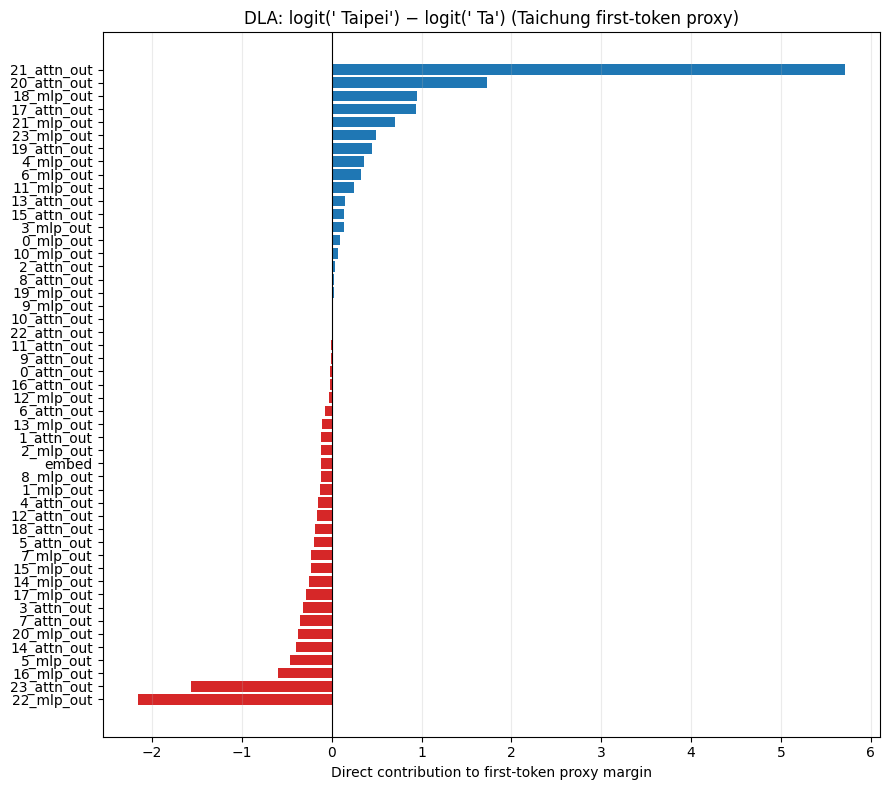

In [11]:
plot_table = dla_table.sort_values(dla_column)
values = plot_table[dla_column].to_numpy()
colors = np.where(values >= 0, "tab:blue", "tab:red")

fig, ax = plt.subplots(figsize=(9, 8))
ax.barh(plot_table["Component"], values, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title(
    f"DLA: logit({TARGET_ANSWER!r}) − logit({competing_first_piece!r}) "
    "(Taichung first-token proxy)"
)
ax.set_xlabel("Direct contribution to first-token proxy margin")
ax.grid(axis="x", alpha=0.25)
fig.tight_layout()
plt.show()

## 8. Optional: experience a pretrained Tuned Lens

A Tuned Lens learns one affine translator per layer before applying the model's final normalization and unembedding. There is no compatible pretrained lens for Qwen2.5-0.5B in the current `tuned-lens` release, so this optional section uses **GPT-2 Small** and its published pretrained translators. It uses the same exact prompt, `The capital of Taiwan is`.

GPT-2 splits both city names into multiple tokens, so a one-step `Taipei − Taichung` margin would not compare the complete answers. Instead, this section compares the full intermediate vocabulary distribution with GPT-2's own final distribution using KL divergence—the quantity the Tuned Lens is trained to improve.

In [12]:
%pip install -q "tuned-lens==0.2.0"

Note: you may need to restart the kernel to use updated packages.


In [13]:
from tuned_lens.nn import TunedLens, Unembed

GPT2_MODEL_NAME = "gpt2-small"
GPT2_PROMPT = "The capital of Taiwan is"

print("Loading GPT-2 Small and its pretrained Tuned Lens...")
gpt2_model = HookedTransformer.from_pretrained(
    GPT2_MODEL_NAME,
    device=device,
    fold_ln=False,
)
gpt2_model.eval()
for parameter in gpt2_model.parameters():
    parameter.requires_grad_(False)

tuned_lens = TunedLens.from_unembed_and_pretrained(
    unembed=Unembed(gpt2_model),
    lens_resource_id="gpt2",
    map_location=device,
).to(device)
tuned_lens.eval()

with torch.inference_mode():
    gpt2_logits, gpt2_cache = gpt2_model.run_with_cache(GPT2_PROMPT)

gpt2_probs = gpt2_logits[0, -1].softmax(dim=-1)
gpt2_top_probs, gpt2_top_ids = torch.topk(gpt2_probs, k=5)
print("GPT-2 prompt:", repr(GPT2_PROMPT))
print("GPT-2 final next-token predictions:")
for rank, (token_id, probability) in enumerate(
    zip(gpt2_top_ids, gpt2_top_probs), start=1
):
    print(
        f"{rank:>2}. {gpt2_model.to_string(token_id)!r:>12}  "
        f"probability={probability.item():.4f}"
    )
print(f"Loaded {len(tuned_lens)} pretrained translators.")

Loading GPT-2 Small and its pretrained Tuned Lens...


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

Loaded pretrained model gpt2-small into HookedTransformer


params.pt:   0%|          | 0.00/28.4M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/191 [00:00<?, ?B/s]

GPT-2 prompt: 'The capital of Taiwan is'
GPT-2 final next-token predictions:
 1.      ' home'  probability=0.0936
 2.         ' a'  probability=0.0551
 3.       ' now'  probability=0.0532
 4.       ' the'  probability=0.0520
 5.        ' in'  probability=0.0266
Loaded 12 pretrained translators.


In [14]:
with torch.inference_mode():
    block_residuals = torch.stack(
        [gpt2_cache["resid_post", layer][0, -1] for layer in range(gpt2_model.cfg.n_layers)]
    )
    logit_lens_logits = gpt2_model.unembed(gpt2_model.ln_final(block_residuals))
    tuned_lens_logits = torch.stack(
        [tuned_lens(block_residuals[layer], layer) for layer in range(gpt2_model.cfg.n_layers)]
    )

# The Tuned Lens is trained to approximate the model's final distribution,
# so KL divergence to that distribution is its most direct evaluation metric.
final_distribution = gpt2_logits[0, -1].softmax(dim=-1)
final_log_distribution = gpt2_logits[0, -1].log_softmax(dim=-1)
logit_lens_kl = torch.sum(
    final_distribution * (
        final_log_distribution - logit_lens_logits.log_softmax(dim=-1)
    ),
    dim=-1,
).cpu().numpy()
tuned_lens_kl = torch.sum(
    final_distribution * (
        final_log_distribution - tuned_lens_logits.log_softmax(dim=-1)
    ),
    dim=-1,
).cpu().numpy()

comparison_rows = []
for layer in range(gpt2_model.cfg.n_layers):
    plain_top_id = logit_lens_logits[layer].argmax().item()
    tuned_top_id = tuned_lens_logits[layer].argmax().item()
    comparison_rows.append(
        {
            "Layer": layer,
            "Logit Lens top token": repr(gpt2_model.to_string(plain_top_id)),
            "Tuned Lens top token": repr(gpt2_model.to_string(tuned_top_id)),
            "Logit Lens KL to final": logit_lens_kl[layer],
            "Tuned Lens KL to final": tuned_lens_kl[layer],
        }
    )

tuned_comparison = pd.DataFrame(comparison_rows)
display(tuned_comparison.round(3))

,Layer,Logit Lens top token,Tuned Lens top token,Logit Lens KL to final,Tuned Lens KL to final
0,0,' not','USS',3.076,7.155
1,1,' not',' not',3.851,1.477
2,2,' now',' a',3.790,1.295
3,3,' now',' now',3.902,1.140
4,4,' now',' the',3.810,1.046
5,5,' now',' now',4.706,1.032
6,6,' now',' a',3.251,0.868
7,7,' now',' now',3.664,0.716
8,8,' now',' a',2.539,0.565
9,9,' now',' the',1.851,0.538


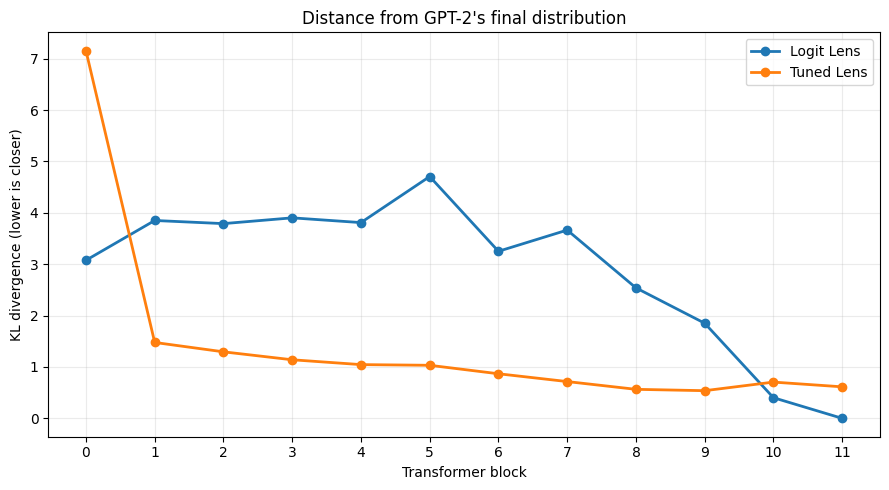

In [15]:
gpt2_layers = np.arange(gpt2_model.cfg.n_layers)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(gpt2_layers, logit_lens_kl, marker="o", linewidth=2, label="Logit Lens")
ax.plot(gpt2_layers, tuned_lens_kl, marker="o", linewidth=2, label="Tuned Lens")
ax.set_title("Distance from GPT-2's final distribution")
ax.set_xlabel("Transformer block")
ax.set_ylabel("KL divergence (lower is closer)")
ax.set_xticks(gpt2_layers)
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
plt.show()

KL divergence measures how closely the whole decoded vocabulary distribution matches GPT-2's final prediction. In this run, the Tuned Lens is closer at most intermediate layers. At the final block, the ordinary Logit Lens is the model's actual final decoder, so its KL divergence is exactly zero.

## 9. Try another factual-recall prompt

Change `PROMPT`, `TARGET_ANSWER`, and `COMPETING_ANSWER` in the setup cell, then run the notebook again. Always inspect how each answer is tokenized before interpreting a one-step logit comparison.